comparing statistics for standard and wta clustering. 
1. number of jets per multiplicity bin
2. differences in Nch
3. maybe differences in number of valid trigger particles?

In [1]:
import ROOT
import numpy as np
import math
import matplotlib.pyplot as plt
import os

In [3]:
filepath = "/Users/rohanjagadeesan/Desktop/Code/li_lab/WinnerTakeAll/output/from_NOTS/3mb_nch60/merged/merged_signals.root"

ROOT.gDirectory.Clear()


In [4]:
analysis_bins = [ [0,25], [25,36], [36,48], [48,60], [60,71], [71,78], [78,91], [91,97], [97,1000] ]

In [61]:
# compare number of jets per bin

def getStats(file_path):
    '''
    from the merged signal file, read for wta and std:
    - number of jets per mult bin
    - avg Nch per mult bin
    '''

    tfile = ROOT.TFile.Open(file_path, "READ")

    wta_num_jets_dict = {}
    std_num_jets_dict = {}

    wta_avg_Nch_dict = {}
    std_avg_Nch_dict = {}

    wta_total_Nch_dict = {}
    std_total_Nch_dict = {}

    for mult_bin in analysis_bins:
        bin_key = f"{mult_bin[0]} <  Nch < {mult_bin[1]}"
        
        # read num jets parameters
        num_jets_wta = tfile.Get(f"num_jets_WTA_{mult_bin[0]}_{mult_bin[1]}").GetVal()
        num_jets_std = tfile.Get(f"num_jets_STD_{mult_bin[0]}_{mult_bin[1]}").GetVal()

        wta_num_jets_dict[bin_key] = num_jets_wta
        std_num_jets_dict[bin_key] = num_jets_std

        # read avg Nch parameters
        avg_Nch_wta = tfile.Get(f"avg_Nch_WTA_{mult_bin[0]}_{mult_bin[1]}").GetVal()
        avg_Nch_std = tfile.Get(f"avg_Nch_STD_{mult_bin[0]}_{mult_bin[1]}").GetVal()

        wta_avg_Nch_dict[bin_key] = avg_Nch_wta
        std_avg_Nch_dict[bin_key] = avg_Nch_std

        # read total Nch parameters
        wta_total_nch = avg_Nch_wta * num_jets_wta
        std_total_nch = avg_Nch_std * num_jets_std

        wta_total_Nch_dict[bin_key] = wta_total_nch
        std_total_Nch_dict[bin_key] = std_total_nch

    return wta_num_jets_dict, std_num_jets_dict, wta_avg_Nch_dict, std_avg_Nch_dict, wta_total_Nch_dict, std_total_Nch_dict



In [62]:
wta_num_jets_dict, std_num_jets_dict, wta_avg_Nch_dict, std_avg_Nch_dict, wta_total_Nch_dict, std_total_Nch_dict = getStats(filepath)

## 1. Jet counts

In [ ]:
num_jets_wta_y_vals = list(wta_num_jets_dict.values())
num_jets_std_y_vals = list(std_num_jets_dict.values())


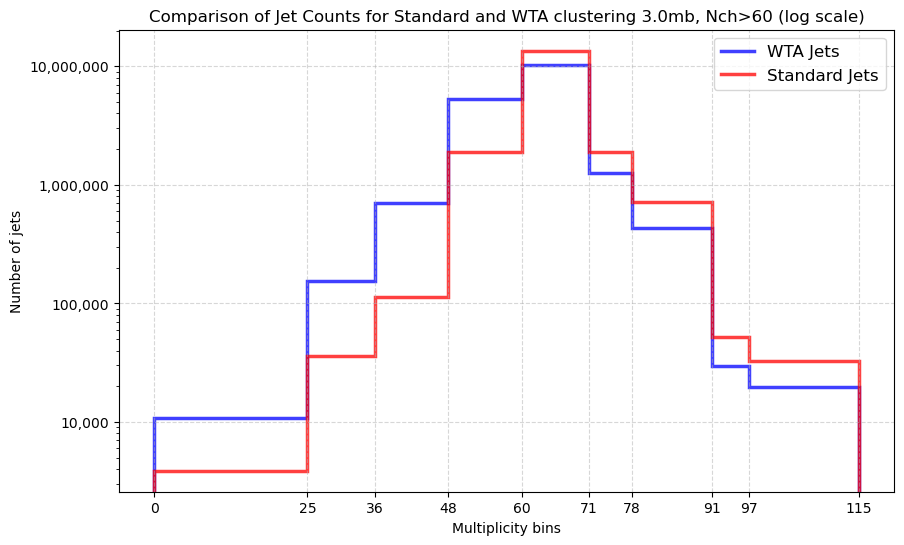

In [36]:
# Plotting step graph
wta_counts = num_jets_wta_y_vals
std_counts = num_jets_std_y_vals
plot_bins = [0, 25, 36, 48, 60, 71, 78, 91, 97, 115]

plt.figure(figsize=(10, 6))

# plt.stairs takes the heights (counts) and the exact bin edges
plt.stairs(wta_counts, plot_bins, label='WTA Jets', color='blue', linewidth=2.5, alpha=0.75)
plt.stairs(std_counts, plot_bins, label='Standard Jets', color='red', linewidth=2.5, alpha=0.75)

# log optional
plt.yscale('log')

# Customizing the layout
plt.title("Comparison of Jet Counts for Standard and WTA clustering 3.0mb, Nch>60 (log scale)")
plt.xlabel("Multiplicity bins")
plt.ylabel("Number of jets")
plt.xticks(plot_bins)

# Format the y-axis with commas for readability
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)


# Save or display the plot
plt.show()

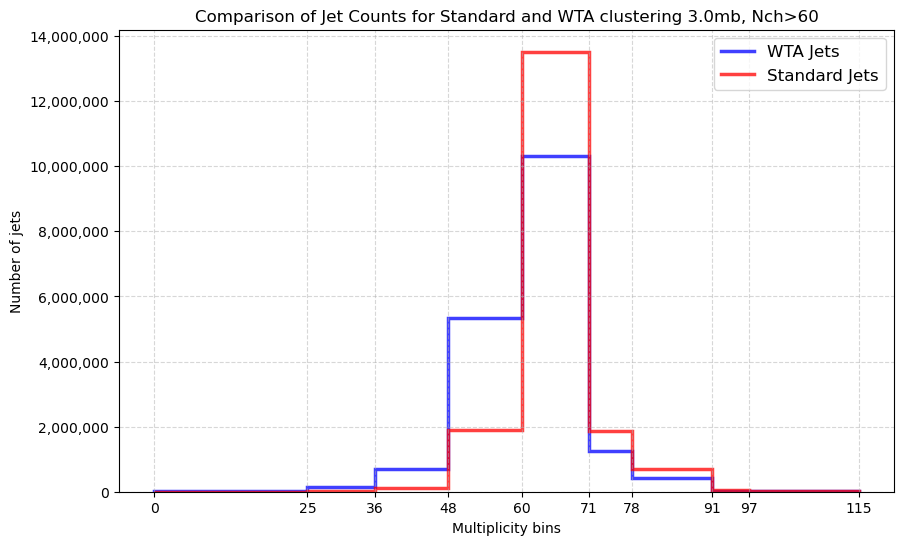

In [37]:
# Plotting step graph non log
wta_counts = num_jets_wta_y_vals
std_counts = num_jets_std_y_vals
plot_bins = [0, 25, 36, 48, 60, 71, 78, 91, 97, 115]

plt.figure(figsize=(10, 6))

# plt.stairs takes the heights (counts) and the exact bin edges
plt.stairs(wta_counts, plot_bins, label='WTA Jets', color='blue', linewidth=2.5, alpha=0.75)
plt.stairs(std_counts, plot_bins, label='Standard Jets', color='red', linewidth=2.5, alpha=0.75)


# Customizing the layout
plt.title("Comparison of Jet Counts for Standard and WTA clustering 3.0mb, Nch>60")
plt.xlabel("Multiplicity bins")
plt.ylabel("Number of jets")
plt.xticks(plot_bins)

# Format the y-axis with commas for readability
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)


# Save or display the plot
plt.show()

In [54]:
num_jets_ratio = []
wta_sum = 0
std_sum = 0

for i in range(len(num_jets_wta_y_vals)):
    num_jets_ratio.append( num_jets_wta_y_vals[i] / num_jets_std_y_vals[i] )
    wta_sum += num_jets_wta_y_vals[i]
    std_sum += num_jets_std_y_vals[i]

print(num_jets_ratio)
print(num_jets_wta_y_vals)
print(num_jets_std_y_vals)

print(wta_sum)
print(std_sum)

[2.7930945632568926, 4.341569889464111, 6.247623113387942, 2.800911540996016, 0.7619918580096542, 0.6684299542409012, 0.609440690664309, 0.5736779446215292, 0.6103254492682023]
[10840.0, 155146.0, 702464.0, 5342848.0, 10299911.0, 1253623.0, 433575.0, 29876.0, 19766.0]
[3881.0, 35735.0, 112437.0, 1907539.0, 13517088.0, 1875474.0, 711431.0, 52078.0, 32386.0]
18248049.0
18248049.0


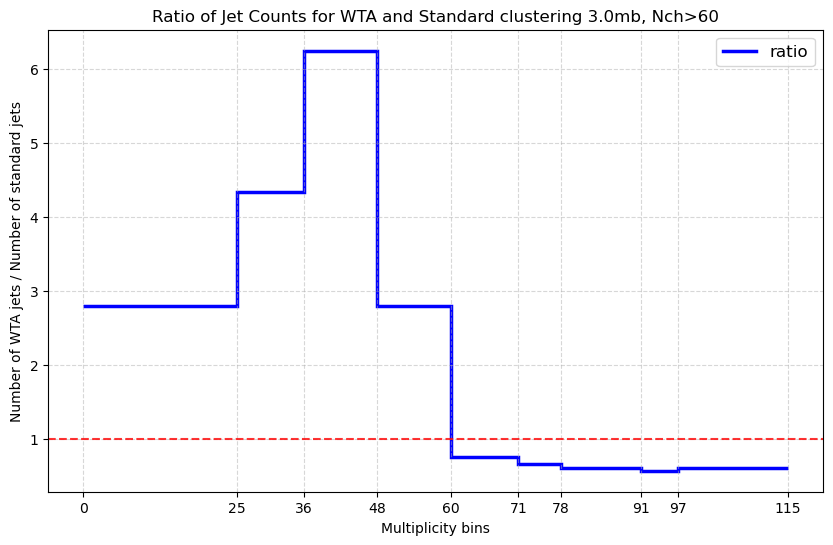

In [46]:
# Plotting step graph non log
counts = num_jets_ratio
plot_bins = [0, 25, 36, 48, 60, 71, 78, 91, 97, 115]

plt.figure(figsize=(10, 6))

# plt.stairs takes the heights (counts) and the exact bin edges
plt.stairs(counts, plot_bins, label='ratio', color='blue', linewidth=2.5, baseline=None)

# Customizing the layout
plt.title("Ratio of Jet Counts for WTA and Standard clustering 3.0mb, Nch>60")
plt.xlabel("Multiplicity bins")
plt.ylabel("Number of WTA jets / Number of standard jets")
plt.xticks(plot_bins)

# Format the y-axis with commas for readability
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.axhline(1.0, color='red', linestyle='dashed', linewidth=1.5, alpha=0.8)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)


# Save or display the plot
plt.show()

## 2. Nch counts

In [47]:
wta_nch_y = list(wta_avg_Nch_dict.values())
std_nch_y = list(std_avg_Nch_dict.values())

In [50]:
nch_ratio = []

for i in range(len(wta_nch_y)):
    nch_ratio.append( wta_nch_y[i] / std_nch_y[i] ) 

print(nch_ratio)

[1.0189511825341155, 1.0093400744251433, 1.0093978456063606, 0.9734574579457842, 0.9982116742304147, 0.9993277829512079, 0.9988618388098077, 1.0000733535877457, 1.0044237649571934]


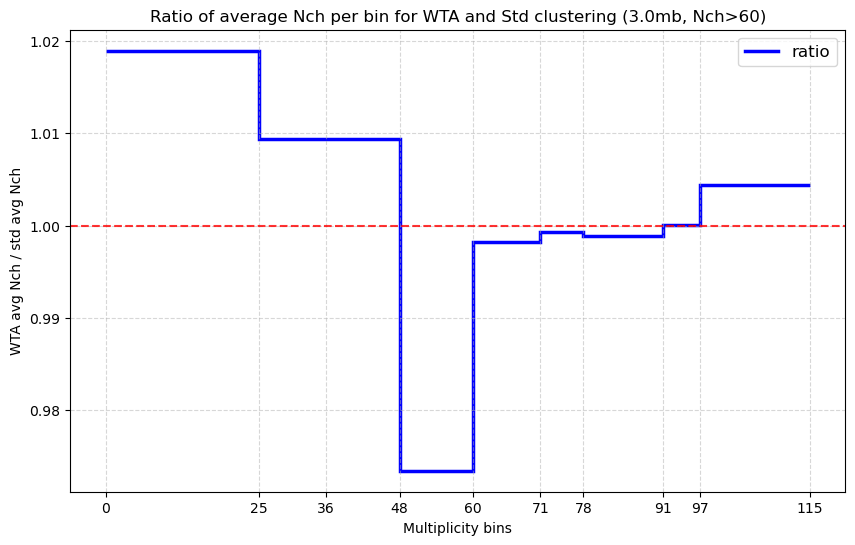

In [52]:
# Plotting step graph non log
counts = nch_ratio
plot_bins = [0, 25, 36, 48, 60, 71, 78, 91, 97, 115]

plt.figure(figsize=(10, 6))

# plt.stairs takes the heights (counts) and the exact bin edges
plt.stairs(counts, plot_bins, label='ratio', color='blue', linewidth=2.5, baseline=None)

# Customizing the layout
plt.title("Ratio of average Nch per bin for WTA and Std clustering (3.0mb, Nch>60)")
plt.xlabel("Multiplicity bins")
plt.ylabel("WTA avg Nch / std avg Nch")
plt.xticks(plot_bins)

# Format the y-axis with commas for readability
#plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.axhline(1.0, color='red', linestyle='dashed', linewidth=1.5, alpha=0.8)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)


# Save or display the plot
plt.show()

In [77]:
# comparing total Nch

wta_nch_sum = sum ( wta_total_Nch_dict.values())
std_nch_sum = sum ( std_total_Nch_dict.values())


print("total WTA Nch:", wta_nch_sum)
print("total STD Nch:", std_nch_sum)
print("Difference (Std - WTA) = ", std_nch_sum - wta_nch_sum)
print("Percent of Std lost = ", 100*(std_nch_sum - wta_nch_sum)/std_nch_sum ,"%")

total WTA Nch: 1121438615.0
total STD Nch: 1178955218.0
Difference (Std - WTA) =  57516603.0
Percent of Std lost =  4.878607950654152 %


## 3. Ntrig counts

In [69]:
def getNtrig(file_path):

    tfile = ROOT.TFile.Open(file_path, "READ")

    wta_Ntrig_dict = {}
    std_Ntrig_dict = {}

    for mult_bin in analysis_bins:
        bin_key = f"{mult_bin[0]} <  Nch < {mult_bin[1]}"
        bin_name = f"{mult_bin[0]}_{mult_bin[1]}"

        hEPD_wta = tfile.Get(f"WTA_epd_{bin_name}")
        hEPD_std = tfile.Get(f"STD_epd_{bin_name}")

        Ntrig_wta = hEPD_wta.GetEntries()
        Ntrig_std = hEPD_std.GetEntries()

        wta_Ntrig_dict[bin_key] = Ntrig_wta
        std_Ntrig_dict[bin_key] = Ntrig_std

    return wta_Ntrig_dict, std_Ntrig_dict
    


In [70]:
wta_Ntrig_dict, std_Ntrig_dict = getNtrig(filepath)
print(wta_Ntrig_dict)
print(std_Ntrig_dict)

{'0 <  Nch < 25': 131748.0, '25 <  Nch < 36': 2945727.0, '36 <  Nch < 48': 18331273.0, '48 <  Nch < 60': 184807320.0, '60 <  Nch < 71': 408567300.0, '71 <  Nch < 78': 57852481.0, '78 <  Nch < 91': 22294425.0, '91 <  Nch < 97': 1736715.0, '97 <  Nch < 1000': 1272509.0}
{'0 <  Nch < 25': 49676.0, '25 <  Nch < 36': 739493.0, '36 <  Nch < 48': 3201904.0, '48 <  Nch < 60': 72608669.0, '60 <  Nch < 71': 569556466.0, '71 <  Nch < 78': 91178465.0, '78 <  Nch < 91': 38421454.0, '91 <  Nch < 97': 3173871.0, '97 <  Nch < 1000': 2176181.0}


In [73]:
wta_ntr = list(wta_Ntrig_dict.values())
std_ntr = list(std_Ntrig_dict.values())

wta_ntr_sum = sum(wta_ntr)
std_ntr_sum = sum(std_ntr)

print("total wta triggers: ", wta_ntr_sum)
print("total std triggers: ", std_ntr_sum)
print("Difference (std-wta) = ", std_ntr_sum - wta_ntr_sum)
print("Percentage difference = ", 100* (std_ntr_sum - wta_ntr_sum) / std_ntr_sum ,"%")

total wta triggers:  697939498.0
total std triggers:  781106179.0
Difference (std-wta) =  83166681.0
Percentage difference =  10.647295237949974 %
